# Stage 14 — Weighted-sum prototype

**Question:** what changes if vulnerability is built as a weighted sum of separate inputs instead of the frozen product-of-maxima structure?

**Structure tested:**

R = karst gate × V × P, where V = Σ wᵢ·xᵢ / Σ wᵢ

- **Karst gate:** V is zero off the mapped karst, so non-karst land has no risk whatever its land use.
- **Pressure P** stays multiplicative. Land use is a hazard, not part of intrinsic vulnerability. It is the frozen catchment-averaged DEA 2020 pressure, recovered from the frozen risk (P = frozen risk ÷ frozen S×C), so it is identical in every structure compared.
- **Six inputs xᵢ, each scaled 0-1:**

| Input | Definition |
|---|---|
| Susceptibility | Karst Atlas category A-D (4-1), ÷ 4 |
| Exposure | exposed 3, covered 2, interstratal 1, ÷ 3 |
| Catchment | proximal catchment 3, distal 1, ÷ 3 |
| Watercourse | stream within 50 m by size (3, 2, 1), ÷ 3 |
| Slope | cell slope ÷ 15 degrees, capped at 1 (steeper = more vulnerable, an assumption) |
| Rainfall | `KAVRAIN` scaled across all mapped karst statewide |

**Weight sets:** equal; "expert" (susceptibility 3, exposure 1, catchment 3, watercourse 2, slope 1, rainfall 1, a rough analogue of EPIK's 3:1:3:2 with epikarst ≈ susceptibility, protective cover ≈ exposure, infiltration ≈ catchment, karst network ≈ watercourse); and 500 random weight vectors.

**How structures are compared:** (1) the pattern against the frozen risk, (2) the independent springs test (system-level, springs valued at the nearest karst cell within 500 m, against a null of all karst cells), and (3) how much the springs result depends on the weights and on each input.

The structures compared, all on vulnerability before pressure is applied:
- **Frozen:** (S/4) × (C/3), with C the highest of exposure, proximal and distal.
- **v2:** the Stage 13 connectivity (slope-scaled catchments, plus watercourse).
- **Weighted sum**, equal and expert weights.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
from rasterio.transform import rowcol
from scipy.ndimage import distance_transform_edt
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, add_connectivity_v2, rasterize_max,
                   in_mole_creek_focus, mole_creek_focus_mask)
from hydro import load_watercourses, score_watercourses, watercourse_raster, mean_slope_by_polygon
from mapping import add_attribution, add_basemap, finish_map, raster_extent

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

NAMES = ["Susceptibility", "Exposure", "Catchment", "Watercourse", "Slope", "Rainfall"]
W_EQUAL = dict.fromkeys(NAMES, 1.0)
W_EXPERT = {"Susceptibility": 3, "Exposure": 1, "Catchment": 3, "Watercourse": 2, "Slope": 1, "Rainfall": 1}
SLOPE_REF_DEG = 15.0
MAX_DIST_M = 500

def slope_degrees(dem, nodata, cell_size):
    z = np.where(dem == nodata, np.nan, dem.astype(float))
    dzdy, dzdx = np.gradient(z, cell_size)
    return np.degrees(np.arctan(np.hypot(dzdx, dzdy)))

def weighted_sum(X, w):
    return sum(w[k] * X[k] for k in NAMES) / sum(w.values())

def corr_nonzero(a, b, valid_mask):
    m = valid_mask & ~np.isnan(a) & ~np.isnan(b) & ((a > 0) | (b > 0))
    return np.corrcoef(a[m], b[m])[0, 1]

def named_ranking(risk, karst_only, shape, transform, valid_mask):
    profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
               "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:
        with mem.open(**profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.dropna(subset=["KNAME"]).groupby("KNAME"):
                img, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = img[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan, "n_px": len(v)})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

def build_inputs(karst, shape, transform, wc, slope, rain_range):
    k = karst.copy()
    k["catchment_score"] = np.maximum(k["proximal_score"], k["distal_score"])
    rmin, rmax = rain_range
    k["rain_norm"] = np.where(k["karst_intensity"] > 0, ((k["KAVRAIN"] - rmin) / (rmax - rmin)).clip(0, 1), 0.0)
    rz = lambda col, dt="uint8": rasterize_max(k, col, shape, transform, fill=0, dtype=dt).astype(float)
    return {
        "Susceptibility": rz("karst_intensity") / 4.0,
        "Exposure": rz("autogenic_score") / 3.0,
        "Catchment": rz("catchment_score") / 3.0,
        "Watercourse": watercourse_raster(wc, shape, transform).astype(float) / 3.0,
        "Slope": np.clip(np.nan_to_num(slope, nan=0.0) / SLOPE_REF_DEG, 0, 1),
        "Rainfall": rz("rain_norm", "float32"),
    }

## 14.1 Inputs

In [2]:
karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
karst_polys = karst_tas[karst_tas["karst_intensity"] > 0]
RAIN_RANGE = (karst_polys["KAVRAIN"].min(), karst_polys["KAVRAIN"].max())
print(f"KAVRAIN across all mapped karst: {RAIN_RANGE[0]:.0f} to {RAIN_RANGE[1]:.0f} mm")

wc = gpd.read_file(outpath / "watercourses_tas_EPSG7855.gpkg")
wc = score_watercourses(wc[wc["HYDLNTY1"] == "Watercourse"] if "HYDLNTY1" in wc.columns else wc)
print(f"Natural watercourses statewide: {len(wc)}")

KAVRAIN across all mapped karst: 549 to 2774 mm


Natural watercourses statewide: 552028


## 14.2 Mole Creek (25 m)

In [3]:
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape; cell = abs(src.transform.a)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    conn_v1 = src.read(1).astype(float)
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src:
    risk_base = src.read(1).astype(float); rn = src.nodata

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)]
risk_base = np.where(valid & (risk_base != rn), risk_base, np.nan)

slope = slope_degrees(dem, dem_nodata, cell)
X = build_inputs(karst_mc, shape, transform, wc, slope, RAIN_RANGE)
gate = valid & (X["Susceptibility"] > 0)

S, C1 = X["Susceptibility"], conn_v1 / 3.0
add_connectivity_v2(karst_mc, mean_slope_by_polygon(karst_mc, slope, transform))
c2_poly = rasterize_max(karst_mc, "connectivity_v2", shape, transform, fill=0, dtype="float32").astype(float)
C2 = np.maximum(c2_poly, X["Watercourse"] * 3.0) / 3.0
P_norm = np.where(gate & (S * C1 > 0), risk_base / np.where(S * C1 > 0, S * C1, 1), 0.0)

V = {"Frozen (S x C)": np.where(gate, S * C1, 0.0),
     "v2 (S x C2)": np.where(gate, S * C2, 0.0),
     "Weighted sum, equal": np.where(gate, weighted_sum(X, W_EQUAL), 0.0),
     "Weighted sum, expert": np.where(gate, weighted_sum(X, W_EXPERT), 0.0)}
R = {k: np.where(valid, v * P_norm, np.nan) for k, v in V.items()}

print("Inputs on the Mole Creek karst (mean, share of cells above 0):")
print(pd.DataFrame({n: {"mean": X[n][gate].mean(), "share > 0": (X[n][gate] > 0).mean()} for n in NAMES}).round(3).T.to_string())
print("\nCorrelation between inputs on the karst:")
print(pd.DataFrame({a: {b: np.corrcoef(X[a][gate], X[b][gate])[0, 1] if X[a][gate].std() > 0 and X[b][gate].std() > 0 else np.nan for b in NAMES} for a in NAMES}).round(2).to_string())

rows = []
for name, r in R.items():
    rows.append({"structure": name, "distinct V values": len(np.unique(V[name][gate].round(4))),
                 "std of V": round(V[name][gate].std(), 3), "mean risk": round(np.nanmean(r[valid]), 3),
                 "r vs frozen risk": round(corr_nonzero(R["Frozen (S x C)"], r, valid), 3)})
print("\n" + pd.DataFrame(rows).to_string(index=False))

table = named_ranking(R["Frozen (S x C)"], karst_only, shape, transform, valid).set_index("KNAME")[["mean_risk", "n_px"]].rename(columns={"mean_risk": "Frozen"})
for name in list(R)[1:]:
    table[name] = named_ranking(R[name], karst_only, shape, transform, valid).set_index("KNAME")["mean_risk"]
print("\nMean risk by Mole Creek area:")
print(table.drop(columns="n_px").round(3).to_string())

Inputs on the Mole Creek karst (mean, share of cells above 0):
                 mean  share > 0
Susceptibility  0.876      1.000
Exposure        0.738      1.000
Catchment       0.283      0.559
Watercourse     0.092      0.151
Slope           0.292      0.786
Rainfall        0.227      1.000

Correlation between inputs on the karst:


                Susceptibility  Exposure  Catchment  Watercourse  Slope  Rainfall
Susceptibility            1.00     -0.02      -0.41        -0.03   0.08     -0.82
Exposure                 -0.02      1.00      -0.31         0.02   0.31     -0.30
Catchment                -0.41     -0.31       1.00         0.04   0.19      0.13
Watercourse              -0.03      0.02       0.04         1.00  -0.05     -0.02
Slope                     0.08      0.31       0.19        -0.05   1.00     -0.25
Rainfall                 -0.82     -0.30       0.13        -0.02  -0.25      1.00

           structure  distinct V values  std of V  mean risk  r vs frozen risk
      Frozen (S x C)                  5     0.212      0.328             1.000
         v2 (S x C2)                 15     0.214      0.323             0.932
 Weighted sum, equal               4264     0.099      0.200             0.341
Weighted sum, expert               4550     0.105      0.214             0.274



Mean risk by Mole Creek area:
                              Frozen  v2 (S x C2)  Weighted sum, equal  Weighted sum, expert
KNAME                                                                                       
Mole Creek  (Chudleigh Hill)   0.484        0.484                0.280                 0.299
Mole Creek                     0.339        0.334                0.194                 0.209
Meander - Western Creek        0.143        0.143                0.297                 0.301


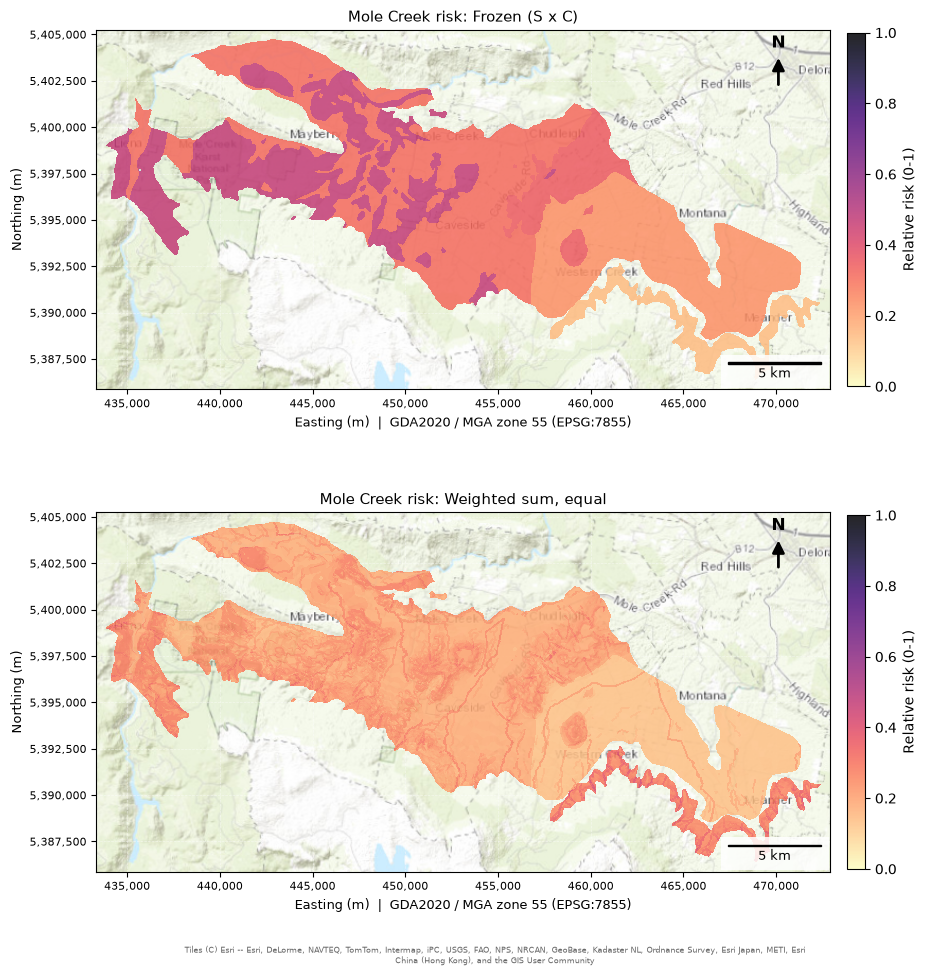

In [4]:
bounds = tuple(karst_only.total_bounds)
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
for ax, name in zip(axes, ["Frozen (S x C)", "Weighted sum, equal"]):
    add_basemap(ax, bounds, margin=500, zoom=11)
    im = ax.imshow(np.ma.masked_where(~valid, R[name]), cmap="magma_r", vmin=0, vmax=1, alpha=0.85,
                   interpolation="nearest", extent=raster_extent(transform, shape), zorder=2)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="Relative risk (0-1)")
    ax.set_title(f"Mole Creek risk: {name}", fontsize=11); finish_map(ax)
add_attribution(axes[-1])
plt.tight_layout(rect=(0, 0.02, 1, 1)); plt.show()

## 14.3 Statewide (100 m)

In [5]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tdem = src.read(1); tnodata = src.nodata; ttransform = src.transform; tshape = tdem.shape; tcell = abs(src.transform.a)
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid = land[0] != tnodata
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tbase = src.read(1).astype(float); trn = src.nodata
tbase = np.where(tvalid & (tbase != trn), tbase, np.nan)

tslope = slope_degrees(tdem, tnodata, tcell)
TX = build_inputs(karst_tas, tshape, ttransform, wc, tslope, RAIN_RANGE)
tgate = tvalid & (TX["Susceptibility"] > 0)
tkarst_only = karst_tas[karst_tas["karst_intensity"] > 0]

tS = TX["Susceptibility"]
tC1 = rasterize_max(karst_tas, "connectivity", tshape, ttransform).astype(float) / 3.0
add_connectivity_v2(karst_tas, mean_slope_by_polygon(karst_tas, tslope, ttransform))
tc2_poly = rasterize_max(karst_tas, "connectivity_v2", tshape, ttransform, fill=0, dtype="float32").astype(float)
tC2 = np.maximum(tc2_poly, TX["Watercourse"] * 3.0) / 3.0
tP = np.where(tgate & (tS * tC1 > 0), tbase / np.where(tS * tC1 > 0, tS * tC1, 1), 0.0)

TV = {"Frozen (S x C)": np.where(tgate, tS * tC1, 0.0),
      "v2 (S x C2)": np.where(tgate, tS * tC2, 0.0),
      "Weighted sum, equal": np.where(tgate, weighted_sum(TX, W_EQUAL), 0.0),
      "Weighted sum, expert": np.where(tgate, weighted_sum(TX, W_EXPERT), 0.0)}
TR = {k: np.where(tvalid, v * tP, np.nan) for k, v in TV.items()}

print("Inputs on mapped karst, statewide (mean, share of cells above 0):")
print(pd.DataFrame({n: {"mean": TX[n][tgate].mean(), "share > 0": (TX[n][tgate] > 0).mean()} for n in NAMES}).round(3).T.to_string())

base_rank = named_ranking(TR["Frozen (S x C)"], tkarst_only, tshape, ttransform, tvalid)
rows = []
ranks = {}
for name, r in TR.items():
    rk = named_ranking(r, tkarst_only, tshape, ttransform, tvalid); ranks[name] = rk
    j = base_rank.merge(rk, on="KNAME", suffixes=("_b", "_v")); j = j[j["n_px_b"] >= 20]
    rows.append({"structure": name, "distinct V values": len(np.unique(TV[name][tgate].round(4))),
                 "std of V": round(TV[name][tgate].std(), 3), "mean risk (karst)": round(np.nanmean(r[tgate]), 3),
                 "r vs frozen risk": round(corr_nonzero(TR["Frozen (S x C)"], r, tvalid), 3),
                 "Spearman, named areas": round(spearmanr(j["mean_risk_b"], j["mean_risk_v"], nan_policy="omit")[0], 3)})
print("\n" + pd.DataFrame(rows).to_string(index=False))
print("\nTop 8 named areas:")
print(pd.concat([ranks[n].head(8)[["KNAME"]].reset_index(drop=True).rename(columns={"KNAME": n}) for n in TR], axis=1).to_string())

Inputs on mapped karst, statewide (mean, share of cells above 0):
                 mean  share > 0
Susceptibility  0.711      1.000
Exposure        0.847      1.000
Catchment       0.194      0.551
Watercourse     0.141      0.235
Slope           0.338      0.905
Rainfall        0.481      0.998



           structure  distinct V values  std of V  mean risk (karst)  r vs frozen risk  Spearman, named areas
      Frozen (S x C)                  7     0.242              0.244             1.000                  1.000
         v2 (S x C2)                 31     0.244              0.245             0.990                  0.995
 Weighted sum, equal               6045     0.119              0.177             0.610                  0.601
Weighted sum, expert               6328     0.116              0.168             0.724                  0.775

Top 8 named areas:
                   Frozen (S x C)                  v2 (S x C2)             Weighted sum, equal            Weighted sum, expert
0  Welcome River (1) / Port Hills                 Geilston Bay  Welcome River (1) / Port Hills  Welcome River (1) / Port Hills
1                    Vinegar Hill                 Vinegar Hill                    Geilston Bay                    Geilston Bay
2              Emita - Memana (2)           Emit

## 14.4 Springs test across structures

The independent check from Stage 10, applied to vulnerability before pressure. Each spring within 500 m of mapped karst takes the vulnerability of its nearest karst cell; one value per nearest named system; compared with 10,000 random same-size draws of karst cells. A higher percentile means springs sit in karst the structure scores as more vulnerable.

In [6]:
gde = gpd.read_file(inpath / "LIST_CFEV_GROUNDWATER_STATEWIDE/list_cfev_groundwater_statewide.shp").to_crs("EPSG:7855")
gde = gpd.clip(gde, tasmania)
kp = karst_tas[karst_tas["karst_intensity"] > 0][["KNAME", "geometry"]].reset_index(drop=True)
near = gpd.sjoin_nearest(gde, kp, how="left", distance_col="dist_poly_m")
near = near[~near.index.duplicated(keep="first")]
near = near[near["dist_poly_m"] <= MAX_DIST_M].copy()

# nearest karst cell for each spring (the cell under a coastal/margin spring is often just off the karst)
_, (ri, ci) = distance_transform_edt(~tgate, return_indices=True)
karst_index = -np.ones(tshape, dtype=np.int64)
rr, cc = np.nonzero(tgate)
karst_index[rr, cc] = np.arange(len(rr))
cells = []
for p in near.geometry:
    r, c = rowcol(ttransform, p.x, p.y)
    cells.append(karst_index[ri[r, c], ci[r, c]] if 0 <= r < tshape[0] and 0 <= c < tshape[1] else -1)
near["kcell"] = cells
near = near[near["kcell"] >= 0].copy()
core_types = ["Tufa-depositing spring", "Cold spring", "Subsurface stream"]
print(f"Springs within {MAX_DIST_M} m of mapped karst: {len(near)} points in {near['KNAME'].nunique()} named systems")

Xk = np.column_stack([TX[n][rr, cc] for n in NAMES])
rng = np.random.default_rng(42)

def springs_percentile(vk, points, n_perm=10000, rng=rng):
    by_sys = pd.Series(vk[points["kcell"].to_numpy()]).groupby(points["KNAME"].to_numpy()).mean()
    null = vk[rng.integers(0, len(vk), size=(n_perm, len(by_sys)))].mean(axis=1)
    return len(by_sys), by_sys.mean(), null.mean(), (null < by_sys.mean()).mean() * 100

vk_struct = {k: v[rr, cc] for k, v in TV.items()}
rows = []
for label, pts in [("all types", near), ("core types", near[near["GDE_TYPE"].isin(core_types)])]:
    for name, vk in vk_struct.items():
        n_sys, g, nm, pct = springs_percentile(vk, pts)
        rows.append({"springs": label, "structure": name, "systems": n_sys, "springs mean V": round(g, 3),
                     "karst mean V": round(nm, 3), "percentile": round(pct, 1)})
print(pd.DataFrame(rows).to_string(index=False))

Springs within 500 m of mapped karst: 79 points in 24 named systems
   springs            structure  systems  springs mean V  karst mean V  percentile
 all types       Frozen (S x C)       24           0.705         0.591        98.9
 all types          v2 (S x C2)       24           0.707         0.594        98.8
 all types  Weighted sum, equal       24           0.445         0.452        39.7
 all types Weighted sum, expert       24           0.413         0.424        33.4
core types       Frozen (S x C)       17           0.731         0.591        99.2
core types          v2 (S x C2)       17           0.732         0.593        99.1
core types  Weighted sum, equal       17           0.455         0.452        54.6
core types Weighted sum, expert       17           0.418         0.424        42.2


## 14.5 How much do the weights and each input matter?

Two checks on the weighted sum, using the springs percentile (all types):
- **Drop one input** from the equal-weight sum, to see which inputs carry the result.
- **500 random weight vectors** (uniform on the simplex), to see the spread.

In [7]:
pts = near
rows = []
vk_eq = Xk @ np.array([W_EQUAL[n] for n in NAMES]) / len(NAMES)
base_pct = springs_percentile(vk_eq, pts)[3]
for k, name in enumerate(NAMES):
    w = np.array([W_EQUAL[n] for n in NAMES]); w[k] = 0
    vk = Xk @ w / w.sum()
    rows.append({"dropped input": name, "springs percentile": round(springs_percentile(vk, pts)[3], 1),
                 "r with equal-weight V": round(np.corrcoef(vk, vk_eq)[0, 1], 3)})
print(f"All six inputs, equal weights: springs percentile {base_pct:.1f}")
print(pd.DataFrame(rows).to_string(index=False))

# each input alone
rows = []
for k, name in enumerate(NAMES):
    rows.append({"input alone": name, "springs percentile": round(springs_percentile(Xk[:, k], pts)[3], 1)})
print("\nEach input on its own:")
print(pd.DataFrame(rows).to_string(index=False))

# random weights
rng_w = np.random.default_rng(7)
W = rng_w.dirichlet(np.ones(len(NAMES)), size=500)
by_sys_idx = pd.Series(np.arange(len(pts))).groupby(pts["KNAME"].to_numpy()).apply(lambda s: s.to_numpy())
null_idx = np.random.default_rng(3).integers(0, len(vk_eq), size=(2000, len(by_sys_idx)))
pcts, rs = [], []
kc = pts["kcell"].to_numpy()
for w in W:
    vk = Xk @ w
    sys_mean = np.array([vk[kc[ix]].mean() for ix in by_sys_idx])
    null = vk[null_idx].mean(axis=1)
    pcts.append((null < sys_mean.mean()).mean() * 100)
    rs.append(np.corrcoef(vk, vk_eq)[0, 1])
pcts, rs = np.array(pcts), np.array(rs)
print(f"\nRandom weights (500 draws): springs percentile 5th/50th/95th = {np.percentile(pcts, 5):.1f} / {np.percentile(pcts, 50):.1f} / {np.percentile(pcts, 95):.1f}; "
      f"share of draws above the 95th percentile: {(pcts > 95).mean() * 100:.0f}%")
print(f"Correlation of V with the equal-weight V across draws: 5th/50th/95th = {np.percentile(rs, 5):.2f} / {np.percentile(rs, 50):.2f} / {np.percentile(rs, 95):.2f}")

All six inputs, equal weights: springs percentile 38.9
 dropped input  springs percentile  r with equal-weight V
Susceptibility                23.6                  0.928
      Exposure                21.7                  0.971
     Catchment                56.6                  0.963
   Watercourse                57.9                  0.922
         Slope                 8.2                  0.881
      Rainfall                85.0                  0.913

Each input on its own:
   input alone  springs percentile
Susceptibility                83.6
      Exposure                96.7
     Catchment                 5.2
   Watercourse                12.0
         Slope                95.4
      Rainfall                 0.3



Random weights (500 draws): springs percentile 5th/50th/95th = 2.2 / 42.0 / 94.8; share of draws above the 95th percentile: 5%
Correlation of V with the equal-weight V across draws: 5th/50th/95th = 0.63 / 0.83 / 0.94


## 14.6 A clean EPIK replication

Section 14.5's "expert" weights are only a rough EPIK analogue: they kept
Rainfall and Slope (real EPIK has neither). This section tests a cleaner
replication: only the four inputs with a direct EPIK factor (Susceptibility
<-Epikarst, Exposure<-Protective cover, Catchment<-Infiltration, Watercourse
<-Karst network), at EPIK's published 3:1:3:2 weight ratio, Rainfall and
Slope weighted 0.


In [ ]:
W_EPIK = {"Susceptibility": 3, "Exposure": 1, "Catchment": 3, "Watercourse": 2, "Slope": 0, "Rainfall": 0}
V_epik = np.where(tgate, weighted_sum(TX, W_EPIK), 0.0)
R_epik = np.where(tvalid, V_epik * tP, np.nan)
vk_epik = V_epik[rr, cc]

rows = []
for label, pts_ in [("all types", near), ("core types", near[near["GDE_TYPE"].isin(core_types)])]:
    n_sys, g, nm, pct = springs_percentile(vk_epik, pts_)
    rows.append({"springs": label, "structure": "EPIK replication", "systems": n_sys,
                 "springs mean V": round(g, 3), "karst mean V": round(nm, 3), "percentile": round(pct, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nDistinct V values: {len(np.unique(V_epik[tgate].round(4)))}")
print(f"r vs frozen risk: {corr_nonzero(TR['Frozen (S x C)'], R_epik, tvalid):.3f}")


**Result:** springs percentile 37.7 (all types) / 39.9 (core types) --
within a few points of the six-input "expert" variant (33.4 / 42.5), nowhere
near the frozen/v2 product (~99). Removing Rainfall and Slope does not close
the gap, which rules out "the extra inputs were diluting it" as the
explanation: the weighted-sum structure itself, not a parameter choice,
costs about 60 percentile points on this test.


## Results

**The weighted sum is a much more detailed map, but a different one.**
- **Resolution:** the frozen product gives 5 distinct vulnerability values at Mole Creek and 7 statewide; the weighted sum gives thousands, because every input contributes.
- **Agreement with the frozen risk:** r = 0.34 (equal weights) and 0.27 (expert weights) at Mole Creek, and r = 0.61 and 0.72 statewide. The rank correlation across named areas is 0.60 and 0.78. Connectivity v2 on its own stays at r = 0.93 and 0.99.
- **Mole Creek areas:** the order changes. Meander - Western Creek rises from 0.14 to 0.30, above the main Mole Creek system (0.19). Why has not been decomposed here.

**The springs test favours the frozen structure.** Springs sit at about the 99th percentile of the karst null for the frozen and v2 structures, but only the 40th (equal weights) and 33rd (expert weights) for the weighted sum.
- **Which inputs carry it:** on their own, exposure (97th percentile), slope (95th) and susceptibility (84th) place springs in higher-scoring karst. Catchment (5th), watercourse (12th) and rainfall (0.3rd) place them in lower-scoring karst.
- **Rainfall:** dropping it lifts the equal-weight sum from the 39th to the 85th percentile. Springs sit in drier karst than average, and rainfall is also strongly anti-correlated with susceptibility at Mole Creek (r = -0.82).
- **Weights:** over 500 random weight vectors the springs percentile has a median of 42 and a 5th to 95th range of 2 to 95. Only 5% of draws exceed the 95th percentile.

**Caveats on reading the springs test:**
- **Discharge, not recharge.** Springs are where water emerges, so the test says little about inputs that describe where water enters (catchment, watercourse, rainfall). Low percentiles for those inputs are expected and are not evidence that they are wrong.
- **Mapping effort.** Springs are mapped where karst has been studied, which may track exposure, region and rainfall for reasons unrelated to vulnerability.
- **Sample size.** There are 24 systems.

**What this says about structure:** once inputs are summed, the choice of inputs and weights decides the answer, and we have no independent data that can choose between them. The product-of-maxima structure is coarser but more stable, and it passes the one independent check we have. The weighted sum is a defensible alternative design, not a better one, until there is evidence to set the weights.

**14.6 adds a direct test of the structural claim.** A clean EPIK replication
(4 inputs with genuine EPIK analogues, true 3:1:3:2 weights, no rainfall or
slope) scores 37.8/39.3 on the springs test -- within a few points of the
rougher 6-input "expert" variant (33.4/42.2), far from the product
structures' ~99. Removing the non-EPIK inputs does not close the gap, so the
~60-point shortfall is attributable to the weighted-sum structure itself,
not to which inputs or weights were chosen.
